In [ ]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, GraphDataLoaderManager, ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeRFModel, NodeLSTMModel, GATv2Model

disease_name    = 'measles'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2017-06-01'
split_valtest   = '2018-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    # log_transform       = ['incidence','population_size'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )
data_orchestrator.data_final.data.loc[data_orchestrator.data_final.data['target_lead1'] > 0, 'target_lead1'] = 1



classification_shallowdata= 


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23265408/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


# Shallowdataloader

In [14]:
import pandas as pd
import pandas as pd
from typing import Literal, Union, List, Dict
from dataclasses import dataclass

from src.utils.textformatting import warning_emoji, checkmark

@dataclass
class ShallowDataLoader:
    """ 
    Stores a single dataloader for shallow models
    """    
    X: pd.DataFrame
    y: pd.DataFrame

    def __post_init__(self):
            # Validate that X and y have the same number of rows
            if len(self.X) != len(self.y):
                raise ValueError(f"X and y have mismatched lengths: X has {len(self.X)} rows, but y has {len(self.y)} rows.")
            
            if len(self.X) == 0:
                raise ValueError(f"No data found. Please check the timestamps used.")

    def __repr__(self):
        return (f"<ShallowDataLoader(X: {len(self.X)} rows, {len(self.X.columns)} cols, " 
                f"y: {len(self.y)} rows)>")     

@dataclass
class ShallowDataLoaderCollection:
    """ 
    Stores all DataLoaders for shallow models

    See Also
    --------
    ShallowDataLoader
    """
    train:              'ShallowDataLoader'
    val:                'ShallowDataLoader'   
    test:               'ShallowDataLoader'
    main:               pd.DataFrame

    def __repr__(self):
        return (f"<ShallowDataLoaderCollection(train, val, test, main)>") 

class ShallowDataLoaderManagerClasses:
    """
    """
    def __init__(self, 
                 dataorchestrator: DataOrchestrator):
        
        self.dataorchestrator     = dataorchestrator
        self.column_registration  = dataorchestrator.column_registration

    def construct_dataloaders(self):
        """
        create dataloader collection classes and store it in `self.dataloader_collections`.
        """
        main_data           = self.dataorchestrator.data_final.data.copy()
        X_col_selection     = [self.dataorchestrator.config.id_column]+self.column_registration.get_by_type('feature')
        self.dataloader_collections: Dict[str, ShallowDataLoaderCollection]    = {}

        for hh in range(self.dataorchestrator.config.horizon_size):
            horizon_name    = f'horizon_{hh}'
            steps_ahead     = int(hh+self.dataorchestrator.config.horizon_leadtime)
            y_col_selection = f'target_lead{steps_ahead}'
            
            main            = main_data[[self.dataorchestrator.config.temporal_column] + X_col_selection + [y_col_selection] + self.column_registration.get_by_type("split")]
            main            = main.rename(columns = {y_col_selection:'target'}).dropna()

            X_train, y_train= main[main['train']][X_col_selection].reset_index(drop = True),  main[main['train']][['target']]
            X_val, y_val    = main[main['val']][X_col_selection].reset_index(drop = True),    main[main['val']][['target']]
            X_test, y_test  = main[main['test']][X_col_selection].reset_index(drop = True),   main[main['test']][['target']]

            dataloader  = ShallowDataLoaderCollection(
                train = ShallowDataLoader(X_train, y_train),
                val   = ShallowDataLoader(X_val, y_val),
                test  = ShallowDataLoader(X_test, y_test),
                main  = main)

            self.dataloader_collections[horizon_name] = dataloader

            if self.dataorchestrator.config.verbose:
                print(f'{checkmark} Dataloader object created for {horizon_name}')

        return self
    
    def __repr__(self):
        return (f"<ShallowDataLoaderManager(dataloaders for {self.dataorchestrator.config.horizon_size} horizons in self.dataloader_collections)>")            

In [ ]:
classified_shallowloader = ShallowDataLoaderManagerClasses(data_orchestrator).construct_dataloaders()

In [23]:
from src.models import PersistenceModel, ClimateologyModel

ps = PersistenceModel(classified_shallowloader, 'persistence - binary')
cm = ClimateologyModel(classified_shallowloader, 'climateology - binary')

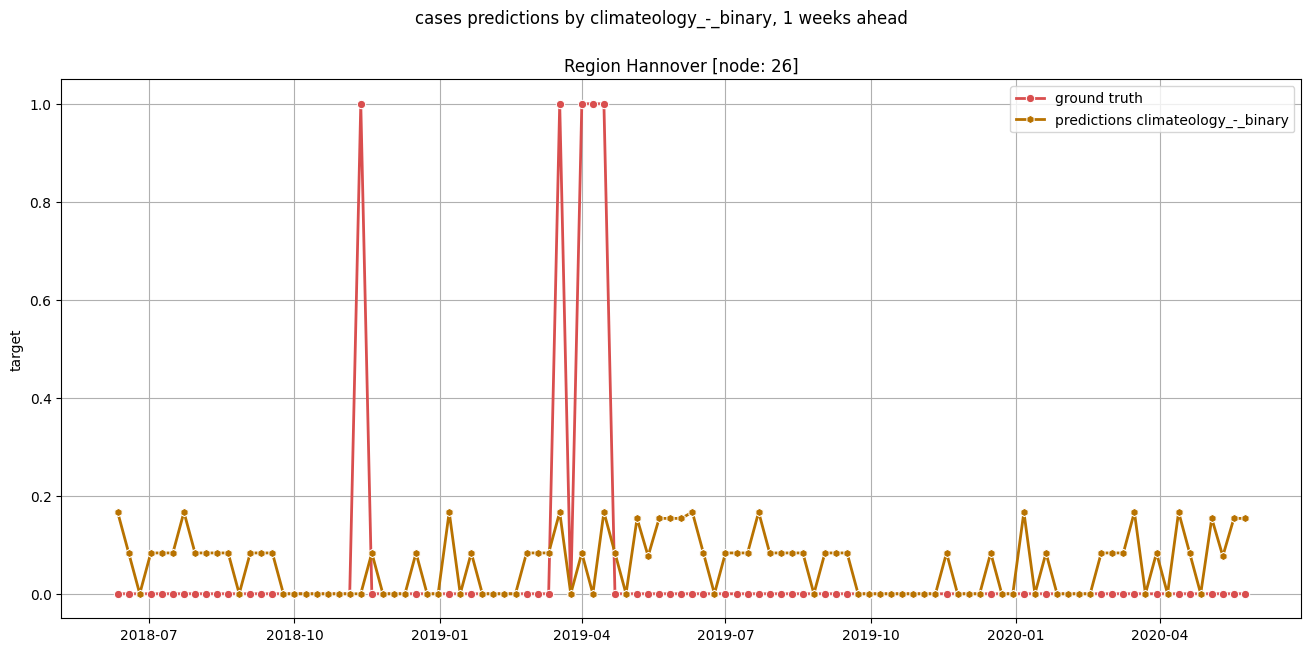

In [ ]:
ps.forecast()
ps.show_forecasts(26).show()